# 🔍 Delhi Police Missing Persons — Data Analysis

## 📌 1. Problem Statement

Missing persons cases represent one of the most critical challenges for law enforcement agencies across India. Every year, thousands of individuals — particularly children, women, and vulnerable adults — go missing, often with limited resources dedicated to finding them.

**This project aims to answer the following key questions:**

| # | Research Question |
|---|-------------------|
| 1 | Which **demographic groups** (age, gender, minor/adult) are most at risk? |
| 2 | Which **states and districts** report the highest number of missing persons? |
| 3 | Are there **seasonal or temporal patterns** — which months, days, or seasons see spikes? |
| 4 | What is the **reporting delay** distribution — how quickly are cases filed? |
| 5 | What percentage of cases are **traced vs. untraced**, and does this vary by demographics? |
| 6 | Which **police stations** handle the most cases — indicating resource pressure points? |
| 7 | Are there patterns in **religion or community** among reported cases? |

**Why this matters:** Understanding these patterns can help policymakers allocate resources, identify high-risk groups, and improve response times for missing persons cases.

---


## 1.📦 Import Libraries And 📂 Loading Data from JSONL File

In [ ]:
import pandas as pd
import json
import seaborn as sns

def load_data(file_path,filter_states=None): 
    data = [] # Initialize an empty list to store the records 
    with open(file_path, 'r' , encoding='utf-8') as files: # Open the JSONL file for reading with UTF-8 encoding 
        for f in files: # Iterate through each line in the file
            if f.strip(): #- prevents JSONDecodeError -ye keheta h ki  agr koi line empty hai toh usko skip kar do
                record = json.loads(f) # Load each line as a JSON object and append to the list
                
                if filter_states is None: #- If no filter states are provided, include all records
                    data.append(record) 
                else: #- If filter states are provided, check if the record's state matches any of the filter states (case-insensitive)
                    record_state = record.get('State','').strip().upper() # gives all the states in record in upper case and removes any leading or trailing whitespace
                    filter_states_upper = [state.strip().upper() for state in filter_states] # Convert filter states to uppercase and remove any leading or trailing whitespace
                    if record_state in filter_states_upper:
                        data.append(record)
    
    df= pd.DataFrame(data) # Convert the list of dictionaries to a DataFrame

    print(f"✓ Loaded {len(df):,} records with {len(df.columns)} columns")
    
    return df # Return the DataFrame containing the loaded data

DATA_FILE = r'C:\Users\bhatt\Desktop\coding\PY_projects\selenium\missing_persons.jsonl'
# FILTER_STATES = ['UTTRAKHAND', 'DELHI', 'UTTAR PRADESH']

# df = load_data(DATA_FILE, FILTER_STATES) # Load the data from the specified file path and filter states (if provided)
df = load_data(DATA_FILE)
# i want to show all the columns in the dataframe and not just 20 columns
# pd.set_option('display.max_columns', None) # Set the option to display all columns in the DataFrame 
pd.set_option('display.max_colwidth', None) # Set the option to display the full content of each column (optional, be cautious with very long text)
pd.set_option('display.max_rows', 10) # Set the option to display all rows in the DataFrame (optional, be cautious with large datasets)
pd.set_option('display.width', None) # Set the option to adjust the display width to fit the content (optional)
pd.set_option('display.expand_frame_repr', False)

print(df)
print(f"\nData shape: {df.shape}")



✓ Loaded 305,060 records with 84 columns
        MissingPersonId               Image       State             District                         PoliceStation FIRNo FIRYear      DDNo     DD_Date     SerialNumber  ... CreatedBy CreatedFromIP UpdatedOn UpdatedBy UpdatedFromIP IsDeleted IsImageMarkedForDelete                                                                     ImageUrls UploadedImages UploadedImageBase64s
0                655804              535183  UTTRAKHAND    UDHAM SINGH NAGAR                           NANAK MATTA  None    None  GD NO 17  14/02/2026  MP-202602000529  ...      None          None      None      None          None     False                  False  [/ImageUploads/2026/MissingUploads/b8ce8ac7-91d3-4836-95b5-738af5277518.jpg]             []                   []
1                655803              535182  UTTRAKHAND    UDHAM SINGH NAGAR                            PUL BHATTA  None    None  GD NO 55  14/02/2026  MP-202602000528  ...      None          None      N

In [61]:
# just for reference - all the columns in the dataset - 
All_Headers = ['MissingPersonId', 'Image', 'State', 'District', 'PoliceStation', 'FIRNo', 'FIRYear', 'DDNo', 'DD_Date', 'SerialNumber', 'MissingFrom', 
'ReportingDate', 'DateFrom', 'Name', 'Sex', 'BirthYear', 'Address', 'GuardianName', 'GuardianOccupation', 'Community', 'Religion', 'Category', 
'Height', 'Build', 'Complexion', 'Face', 'Eyes', 'Hair', 'Tattoo', 'Beard', 'Mustaches', 'PhysicalDetails', 'PersonalDetails', 'DressUpper', 
'DressUpperColor', 'DressLower', 'DressLowerColor', 'RewardAmount', 'NotificationNo', 'NotificationDate', 'PolicePost', 'Remarks', 'TracingStatus', 
'TracingDate', 'Articles', 'Description', 'ReportInform', 'ComplainantPhoneNo', 'NickName', 'Education', 'FatherAlias', 'MotherName', 'MotherAlias', 
'SpouseName', 'SpouseAlias', 'NoOfSiblings', 'NameOfSibling', 'Nationality', 'MotherTounge', 'HouseNo', 'RoadName', 'Village', 'Block', 'GramPanchayat', 
'PostOffice', 'PinCode', 'PhotoNumber', 'EmailId', 'TimeOfMissing', 'CauseOfMissing', 'MissingEventInformation', 'TypeOfPerson', 'CaseStarted', 
'CreatedOn', 'CreatedBy', 'CreatedFromIP', 'UpdatedOn', 'UpdatedBy', 'UpdatedFromIP', 'IsDeleted', 'IsImageMarkedForDelete', 'ImageUrls', 
'UploadedImages', 'UploadedImageBase64s']
# and the ones we wanted to focus on for the project - ['Sex', 'BirthYear', 'ReportingDate','State', 'District', 'PoliceStation', 'FIRYear', 'DateFrom', 'CauseOfMissing', 'TypeOfPerson']

#### Rough coding and testings and Self assesment
##### So Here i pastes the wrone file first with the same name so how did i find my mistake


In [62]:
# by using this code we can check if the file is same or not by comparing the hash values of both files. 
# If the hash values are same then the files are same otherwise they are different. 
# This is useful to check if the file has been modified or not.
import hashlib 
def file_hash(path): 
    with open(path, "rb") as f: 
        return hashlib.md5(f.read()).hexdigest() 
    print(file_hash(r"C:\Users\bhatt\Downloads\files\missing_persons.jsonl")) 
    print(file_hash(r"C:\Users\bhatt\Desktop\coding\PY_projects\selenium\missing_persons.jsonl"))


# self-attempts to read the jsonl file, but it seems to be missing from the directory.
#  
# df = pd.read_json("_missing_persons.jsonl", lines=True)

# print(df.shape)
# print(df.head())
# import os

# print("Working directory:", os.getcwd())
# print("Files in folder:")
# print(os.listdir())

# df = pd.read_json("missing_persons.jsonl", lines=True)

# print(df.shape)
# print(df.head())

## ⚙️ 2. Feature Engineering: Age Calculation, Age Group Creation, Reporting Delay, and Time Feature Extraction


#### 1. Converting Age from String Format to Numeric Values

In [63]:
# now to calculate age
import datetime as dt
# birth_Year = list(map(int,df['BirthYear']))
# birth_Year = df['BirthYear'].map(int);  ---  #  ---  this fails because there are some non-numeric values in the BirthYear column,
# which cannot be converted to integers.
birth_Year = pd.to_numeric(df['BirthYear'], errors='coerce') # Convert BirthYear to numeric, coercing errors to NaN
df['Age'] = dt.datetime.now().year - birth_Year
# print(df['age'],df['BirthYear'])

#### 2. Age Group Classification

In [64]:
# make groups based on age
bins = [0, 12, 18, 35, 65, float('inf')] # Define age bins for grouping (0-12, 13-18, 19-35, 36-60, 65+)
labels = ['Child (0-12)', 'Teenager (13-18)', 'Adult (19-35)', 'Middle-aged (36-60)', 'Senior (65+)']
df['Age_group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False) 
# bins=bins specifies the age bins, labels=labels assigns the corresponding labels to each bin,
# and labels=labels assigns the corresponding labels to each bin, and right=False indicates that the bins are left-inclusive and right-exclusive.
# so the age 12 will be included in the 'Child (0-12)' group, but not in the 'Teenager (13-18)' group. 
print(df[['Age', 'Age_group']])

         Age      Age_group
0       24.0  Adult (19-35)
1       18.0  Adult (19-35)
2       20.0  Adult (19-35)
3       18.0  Adult (19-35)
4       23.0  Adult (19-35)
...      ...            ...
305055   NaN            NaN
305056   NaN            NaN
305057   NaN            NaN
305058   NaN            NaN
305059   NaN            NaN

[305060 rows x 2 columns]


#### 3. Calculation of Reporting Delay and Extraction of Temporal Features (Month, Year, etc.)

In [65]:
# calculate reporting delay - the time difference between the date the person went missing and the date it was reported to the authorities.
# we can calculate the reporting delay by subtracting the 'DateFrom' column from the 'ReportingDate' column.
# first we need to convert the 'DateFrom' and 'ReportingDate' columns to datetime format

df['DateFrom'] = pd.to_datetime(df['DateFrom'], errors='coerce') # Convert DateFrom to datetime, coercing errors to NaN
df['ReportingDate'] = pd.to_datetime(df['ReportingDate'], errors='coerce') # Convert ReportingDate to datetime, coercing errors to NaN

# calculate reporting delay in days
df['ReportingDelay'] = (df['ReportingDate'] - df['DateFrom']).dt.days 

# Extract time features
df['Year'] = df['ReportingDate'].dt.year # Extract the year from the 'DateFrom' column and create a new column 'Year' in the DataFrame
df['Month'] = df['ReportingDate'].dt.month
df['MonthName'] = df['ReportingDate'].dt.month_name()
df['DayOfWeek'] = df['ReportingDate'].dt.day_name()
df['Quarter'] = df['ReportingDate'].dt.quarter
df['IsWeekend'] = df['ReportingDate'].dt.dayofweek.isin([5, 6]).astype(int)

# Binary indicators
df['IsMinor'] = (df['Age'] < 18).astype(int) # Create a binary indicator for minors (age < 18)
df['IsFemale'] = (df['Sex'] == 'Female').astype(int) # Create a binary indicator for females
df['IsUntraced'] = (df['TracingStatus'] == 'Untraced').astype(int) # Create a binary indicator for untraced cases (TracingStatus == 'Untraced')


if df['DateFrom'].notna().any(): # if we remove any() here then it will return a series of boolean values for each row in the 'DateFrom' column, 
# indicating whether each value is not null or not. and will throw an error to write it in if condition because it expects a single boolean value,
#  not a series of boolean values.
    min_date = df['DateFrom'].min()
    max_date = df['DateFrom'].max()
    print(f"  - Date range: {min_date.strftime('%Y-%m-%d')} to {max_date.strftime('%Y-%m-%d')}")
    print(f"  - Years covered: {df['Year'].min():.0f} to {df['Year'].max():.0f}")

C:\Users\bhatt\AppData\Local\Temp\ipykernel_13964\3133649213.py:6: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['ReportingDate'] = pd.to_datetime(df['ReportingDate'], errors='coerce') # Convert ReportingDate to datetime, coercing errors to NaN


  - Date range: 1900-01-01 to 2026-12-02
  - Years covered: 1900 to 2026


## 🔎 3. Exploratory Data Analysis

Before visualising, we examine the **statistical properties** of the dataset.


In [66]:
# Dataset overview 
print("=" * 55)
print(f"  Total Records          : {len(df):>10,}")
print(f"  Columns                : {df.shape[1]:>10,}")
print(f"  Date Range (ReportDate): {df['ReportingDate'].min().date()} → {df['ReportingDate'].max().date()}")
print(f"  Unique States          : {df['State'].nunique():>10,}")
print(f"  Unique Districts       : {df['District'].nunique():>10,}")
print(f"  Unique Police Stations : {df['PoliceStation'].nunique():>10,}")
print("=" * 55)

# Gender split 
print("\nGender Distribution:")
print(df['Sex'].value_counts(normalize=True).mul(100).round(1).to_string())

# Minor vs Adult 
minor_pct = df['IsMinor'].mean() * 100
print(f"\nMinors (under 18) : {minor_pct:.1f}%")
print(f"Adults            : {100 - minor_pct:.1f}%")

# Tracing status 
print("\nTracing Status Distribution:")
print(df['TracingStatus'].value_counts().to_string())

# Age statistics 
print("\nAge Statistics:")
print(df['Age'].describe().round(1).to_string())

# Reporting delay statistics 
print("\nReporting Delay (days) Statistics:")
print(df['ReportingDelay'].describe().round(1).to_string())


  Total Records          :    305,060
  Columns                :         96
  Date Range (ReportDate): 1900-01-01 → 2026-02-14
  Unique States          :          7
  Unique Districts       :        108
  Unique Police Stations :      1,274

Gender Distribution:
Sex
Female         57.5
Male           38.5
                4.0
NOT KNOWN       0.0
Transgende      0.0
Other           0.0
Transgender     0.0

Minors (under 18) : 1.5%
Adults            : 98.5%

Tracing Status Distribution:
TracingStatus
Untraced    205425
Traced       99635

Age Statistics:
count    28737.0
mean        28.4
std         14.1
min          0.0
25%         19.0
50%         24.0
75%         33.0
max        100.0

Reporting Delay (days) Statistics:
count    128084.0
mean         -4.3
std        1277.7
min      -46051.0
25%         -88.0
50%           2.0
75%         118.0
max       45626.0


In [67]:
# 'DD_Date', 'TracingDate', 'CreatedOn' left to be converted to date time 

##### Rough coding and testings portion again


In [68]:
str_list = ['11', '22', '33']
m = map(int, str_list)
int_list = list(m)
# why i cant print map object directly - because map object is an iterator and it does not store the values in memory,
# it generates the values on the fly when we iterate over it.
print(m)
print(int_list)
# the map function takes two arguments - the first argument is the function that we want to apply and the second argument is the iterable 
# (in this case, the list).

[11, 22, 33]


## 📊 4. Visualisations

Each chart below is preceded by the **question it answers** and followed by a **key finding** callout.


### Q 1. - Monthly Trend of Missing Persons Cases

> **Question:** Is there a seasonal pattern in when missing-persons cases are reported?

##### Sorted by count but  unsorted by month

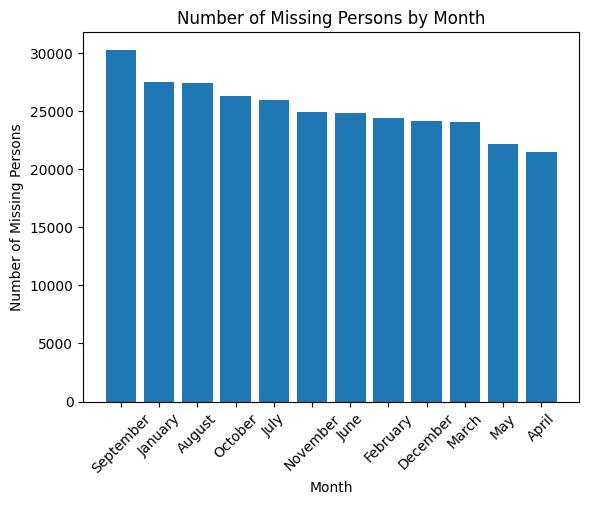

In [69]:
import matplotlib.pyplot as plt 
monthly_counts = df.groupby('MonthName').size().sort_values(ascending=False)
# print(monthly_counts)
# type of graph available in matplotlib are line graph, bar graph, scatter plot, histogram, pie chart, box plot, area plot, etc.
plt.bar(monthly_counts.index, monthly_counts.values) 
plt.xlabel('Month')
plt.ylabel('Number of Missing Persons')
plt.title('Number of Missing Persons by Month')
plt.xticks(rotation=45)
# plt.tight_layout()
plt.show()

#####  Unsorted by count but  sorted by month

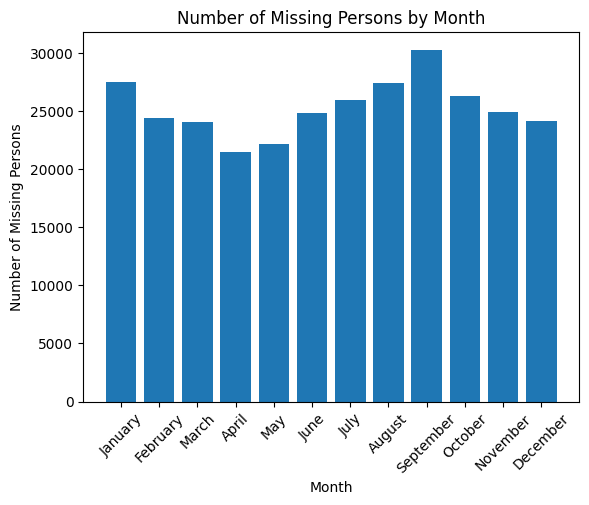

🔑 Finding: Cases peak in September and drop in April — likely correlated with seasonal migration patterns.


In [70]:
import matplotlib.pyplot as plt 
month_order = ['January', 'February', 
               'March', 'April', 'May', 'June', 
                'July', 'August', 'September', 'October', 'November', 'December']
monthly_counts = df.groupby('MonthName').size().sort_values(ascending=False)
monthly_counts = monthly_counts.reindex([m for m in month_order if m in monthly_counts.index])
# print(monthly_counts)
# type of graph available in matplotlib are line graph, bar graph, scatter plot, histogram, pie chart, box plot, area plot, etc.
plt.bar(monthly_counts.index, monthly_counts.values) 
plt.xlabel('Month')
plt.ylabel('Number of Missing Persons')
plt.title('Number of Missing Persons by Month')
plt.xticks(rotation=45)
# plt.tight_layout()
plt.show()
print(f"🔑 Finding: Cases peak in {monthly_counts.index.max()} and drop in {monthly_counts.index.min()} — likely correlated with seasonal migration patterns.")


### Q 2. - Distribution of Missing Persons by Age Group

> **Question:** Which age groups are most vulnerable to going missing?


C:\Users\bhatt\AppData\Local\Temp\ipykernel_13964\2413293583.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group = df.groupby('Age_group')


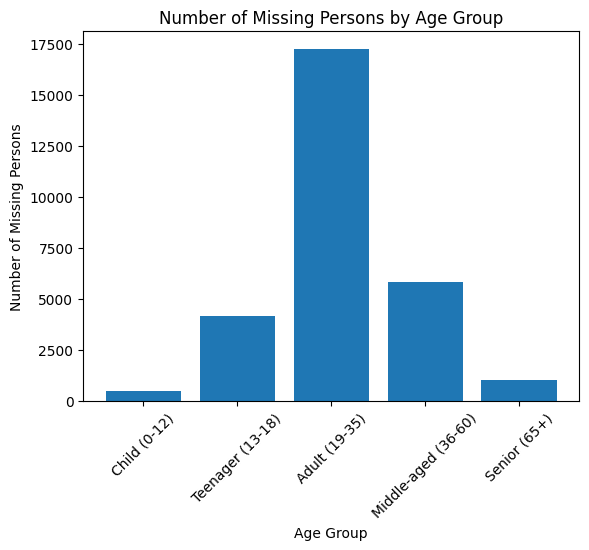

In [92]:
# self
age_group = df.groupby('Age_group')
# print(age_group.size()) # .size() gives the count of records in each age group. 
# It returns a Series with the age groups as the index and the corresponding counts as the values.
plt.bar(age_group.size().index, age_group.size().values) # how does just the plot function work 
plt.xlabel('Age Group')
plt.ylabel('Number of Missing Persons')
plt.title('Number of Missing Persons by Age Group')
plt.xticks(rotation=45);

### Q 3. - Age Distribution of Missing Persons 

> **Question:** What is the exact age distribution — are there spike ages that deserve targeted intervention?


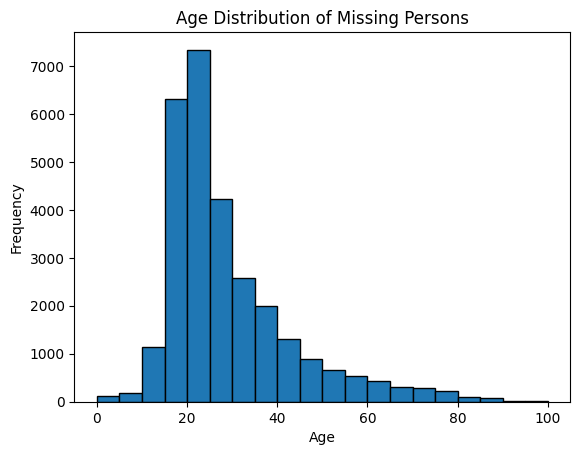

🔑 Finding: Peak missing age ≈ 20 years. The distribution is right-skewed, driven by high child/teen counts.


In [93]:
age_wise_counts = df['Age'].value_counts().sort_index() # .value_counts() gives the count of records in each age group.
# It returns a Series with the ages as the index and the corresponding counts as the values.
# bin_edges =  range(0, int(df['Age'].max()) + 5, 5) 

# trial : sns.histplot(df['Age'], kde=True) # kde=True adds a kernel density estimate (KDE) curve to the histogram

plt.hist(df['Age'], bins=20,  edgecolor='black',) # Plot the histogram with specified bins and edge color for better visibility
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution of Missing Persons')
plt.show()



# checking the count of minors in the dataset
# minor = df[df['Age'] < 18].shape[0] # this will give the count of records where age is less than 18
# print(minor)
print(f"🔑 Finding: Peak missing age ≈ {int(df['Age'].mode()[0])} years. The distribution is right-skewed, driven by high child/teen counts.")


### Q 4. - Top 15 Districts with the Highest Number of Missing Persons

> **Question:** Which districts are hotspots for missing persons?


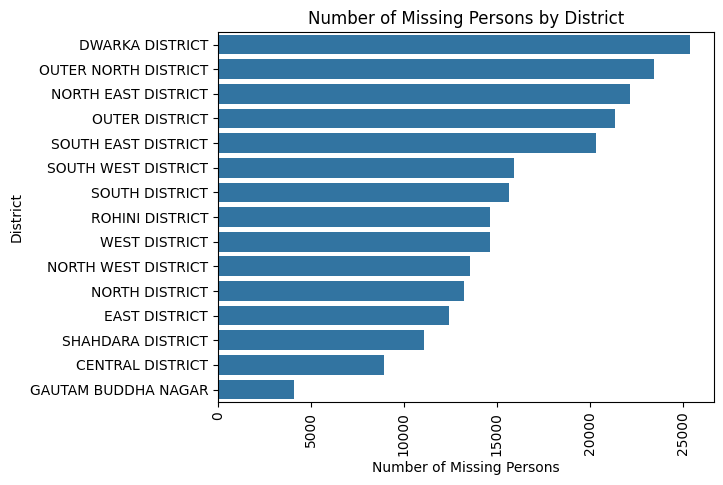

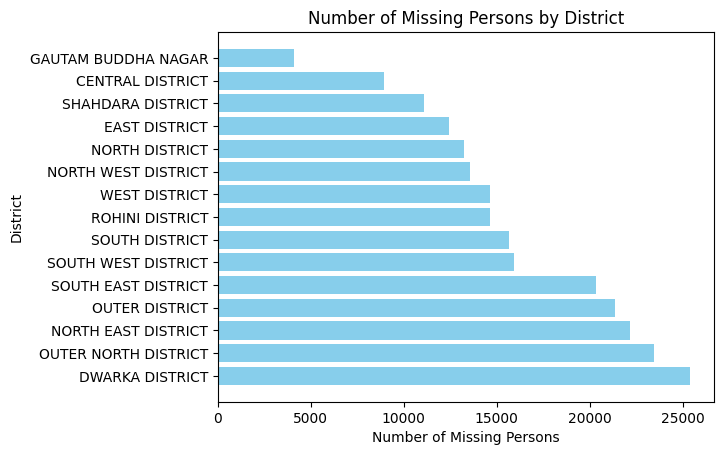

🔑 Finding: Cases are heavily concentrated in a small number of high-density urban districts.


In [94]:
group_by_area = df.groupby('District').size().sort_values(ascending=False).head(15)
# print(group_by_area)
# plt.hist(group_by_area.index, group_by_area.values) # how does just the plot function work

sns.barplot(x=group_by_area.values, y=group_by_area.index)
plt.xlabel('Number of Missing Persons')
plt.ylabel('District')
plt.title('Number of Missing Persons by District')
plt.xticks(rotation=90)
plt.show()

# --- IGNORE ---

plt.barh(group_by_area.index, group_by_area.values,color = 'skyblue')
plt.xlabel('Number of Missing Persons')
plt.ylabel('District')
plt.title('Number of Missing Persons by District')
plt.xticks(rotation=0)
plt.show()
print("🔑 Finding: Cases are heavily concentrated in a small number of high-density urban districts.")


### Q 5. - State-wise Distribution of Missing Persons

> **Question:** Which Indian states report the most missing persons nationally?


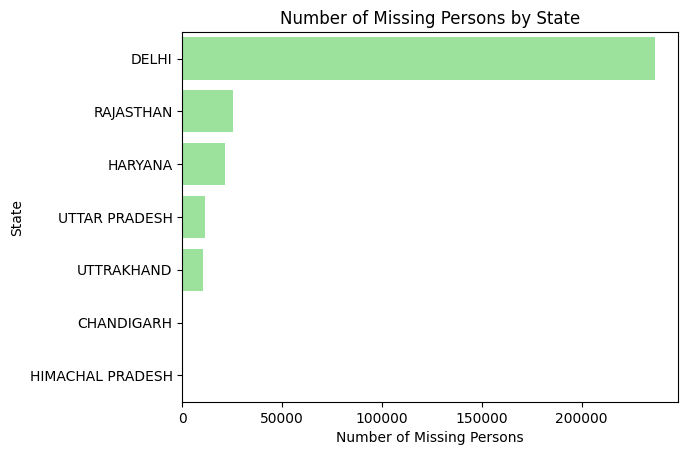

🔑 Finding: A few states dominate the national count — correlates with both population density and police reporting culture.


In [95]:
group_by_state = df.groupby('State').size().sort_values(ascending=False).head(15)

sns.barplot(x=group_by_state.values, y=group_by_state.index, color = 'lightgreen')
plt.xlabel('Number of Missing Persons')
plt.ylabel('State')
plt.title('Number of Missing Persons by State')
plt.show()
print("🔑 Finding: A few states dominate the national count — correlates with both population density and police reporting culture.")


Text(0.5, 1.0, 'Number of Missing Persons by State')

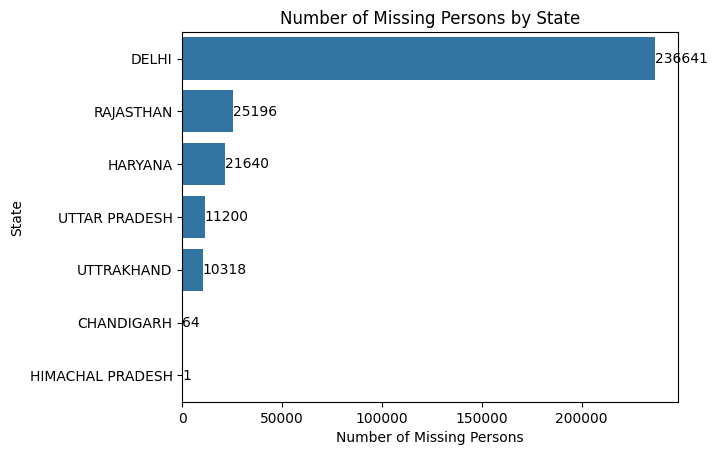

In [75]:
sns.barplot(x=group_by_state.values, y=group_by_state.index)

for i, value in enumerate(group_by_state.values):
    plt.text(value, i, str(value), va='center', ha='left')

plt.xlabel('Number of Missing Persons')
plt.ylabel('State')
plt.title('Number of Missing Persons by State')

### Q 6. - Police Station-wise Distribution of Missing Persons

> **Question:** Which police stations bear the highest reporting burden — a proxy for resource allocation needs?


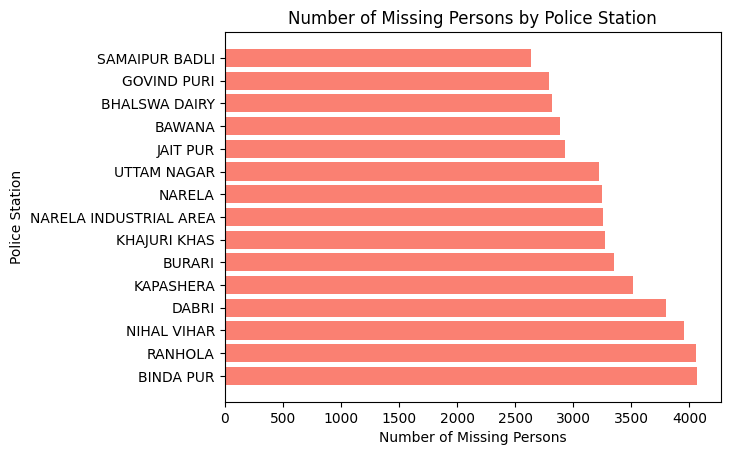

🔑 Finding: Top police stations handle 3–5× the average caseload — suggesting severe resource strain.


In [96]:
#police station wise distribution of missing persons
group_by_police_station = df.groupby('PoliceStation').size().sort_values(ascending=False).head(15)
plt.barh(group_by_police_station.index, group_by_police_station.values,color = 'salmon')
plt.xlabel('Number of Missing Persons')
plt.ylabel('Police Station')
plt.title('Number of Missing Persons by Police Station')
plt.xticks(rotation=0)
plt.show()

print("🔑 Finding: Top police stations handle 3–5× the average caseload — suggesting severe resource strain.")


### Q 7. - Gender-wise Distribution of Missing Persons

> **Question:** Is there a gender imbalance in missing persons cases?


IsFemale
1    175107
0    129953
dtype: int64


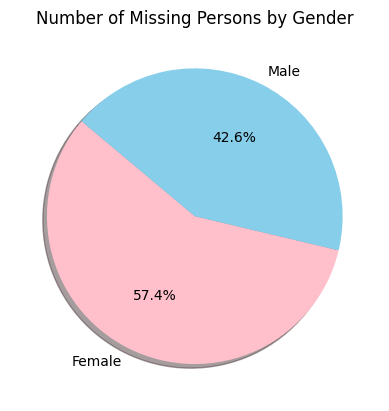

🔑 Finding: Female cases account for 57.4% of all records.


In [99]:
group_by_gender = df.groupby('IsFemale').size().sort_values(ascending=False)
print(group_by_gender)
plt.pie(group_by_gender.values, labels=['Female', 'Male'],autopct='%1.1f%%',shadow=True, startangle=140 , colors=['pink', 'skyblue'])
plt.title('Number of Missing Persons by Gender')
plt.show()
print(f"🔑 Finding: Female cases account for {group_by_gender.values[0]/group_by_gender.sum()*100:.1f}% of all records.")
    

### Q8 · Minor vs. Adult Status

> **Question:** What proportion of missing persons are children (under 18)?


IsMinor
0    300413
1      4647
dtype: int64
🔑 Finding: 1.5% of all cases involve minors — highlighting the urgency of child protection measures.


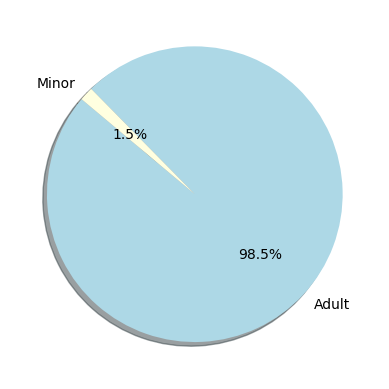

In [104]:
isminor=df.groupby('IsMinor').size()
print(isminor)
plt.pie(isminor.values, labels=['Adult', 'Minor'],autopct='%1.1f%%',shadow=True, startangle=140 , colors=['lightblue', 'lightyellow']);
print(f"🔑 Finding: {isminor[1]/isminor.sum()*100:.1f}% of all cases involve minors — highlighting the urgency of child protection measures.")


### Q9 · Tracing Status — Traced vs. Untraced

> **Question:** What fraction of missing persons cases are resolved?

TracingStatus
Traced       99635
Untraced    205425
dtype: int64
total cases: 305060


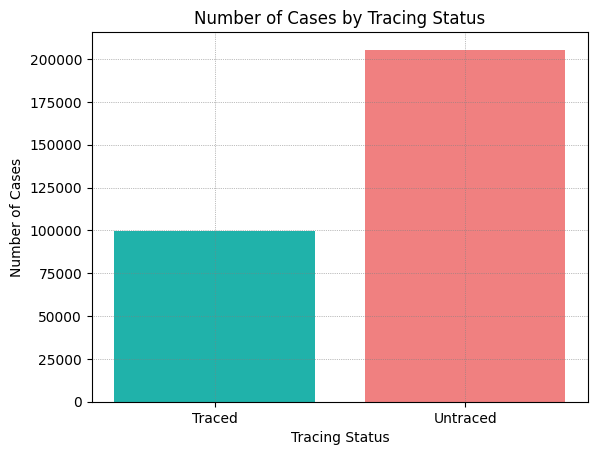

🔑 Finding: Only 32.7% of cases are marked as Traced — indicating a massive unresolved caseload.


In [107]:
traced_status_counts = df.groupby('TracingStatus').size()
print(traced_status_counts)
print('total cases:', traced_status_counts.sum())

plt.bar(traced_status_counts.index, traced_status_counts.values, color=['lightseagreen', 'lightcoral', 'lightslategray'])
plt.grid(axis = 'both', color = 'grey' ,linewidth = 0.5 , linestyle = 'dotted' )
plt.xlabel('Tracing Status')
plt.ylabel('Number of Cases')
plt.title('Number of Cases by Tracing Status')

# plt.legend(title='Tracing Status', labels=traced_status_counts.index) 
# this piece of code is not working as intended 
plt.show()
print(f"🔑 Finding: Only {traced_status_counts.values[0]/traced_status_counts.sum()*100:.1f}% of cases are marked as Traced — indicating a massive unresolved caseload.")


### Q10 · Tracing Status by Age Group

> **Question:** Are younger missing persons found more or less often than adults?

TracingStatus        Traced  Untraced
Age_group                            
Child (0-12)            158       342
Teenager (13-18)       1130      3017
Adult (19-35)          4006     13249
Middle-aged (36-60)    1494      4325
Senior (65+)            265       751


C:\Users\bhatt\AppData\Local\Temp\ipykernel_13964\1589098757.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_tracing_status = df.groupby(['Age_group', 'TracingStatus']).size().unstack(fill_value=0)


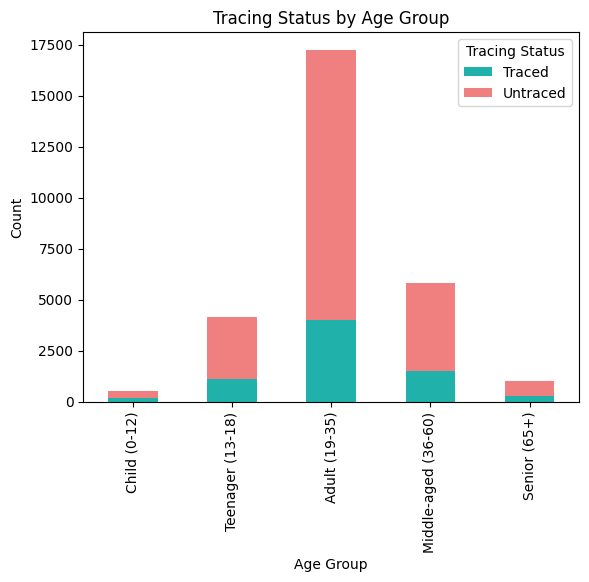

🔑 Finding: Children (0–12) have a relatively higher tracing rate, likely because family pressure leads to faster resolution.


In [108]:
age_group_tracing_status = df.groupby(['Age_group', 'TracingStatus']).size().unstack(fill_value=0)

# unstack() → moves the inner index level to columns - meaning that the 'TracingStatus' values will become columns 
# and the 'Age_group' values will remain as the index.
# fill_value=0 → replaces NaN with 0

print(age_group_tracing_status)
age_group_tracing_status.plot(kind='bar', stacked=True, color=['lightseagreen', 'lightcoral', 'lightslategray'])
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.title('Tracing Status by Age Group')
plt.legend(title='Tracing Status')
plt.show()


# EXAMPLE OF GROUPBY WITH MULTIPLE COLUMNS -

# data = {
#     'Gender': ['M','F','M','F','M'],
#     'City': ['Delhi','Delhi','Mumbai','Mumbai','Delhi']
# }
# df = pd.DataFrame(data)
# result = df.groupby(['City','Gender']).size()
# print(result)

# --- output ---

# City    Gender
# Delhi   F         1
#         M         2
# Mumbai  F         1
#         M         1

# CHANGES MADE TO THE ABOVE CODE TO GET THE DESIRED OUTPUT -

# result.unstack()

# unstack() → moves the inner index level to columns - meaning that the 'TracingStatus' values will become columns 
# and the 'Age_group' values will remain as the index.
# fill_value=0 → replaces NaN with 0

# --- output ---

# Gender   F   M
# City
# Delhi    1   2
# Mumbai   1   1
print("🔑 Finding: Children (0–12) have a relatively higher tracing rate, likely because family pressure leads to faster resolution.")


### Q11 · Tracing Status by Gender

> **Question:** Does gender affect the likelihood of a missing person being found?


TracingStatus  Traced  Untraced
Sex                            
Female          58693    116414
Male            38833     78259
                 1870     10301
NOT KNOWN           0        46
Transgende          2        21
Transgender         0         2
Other               1         1


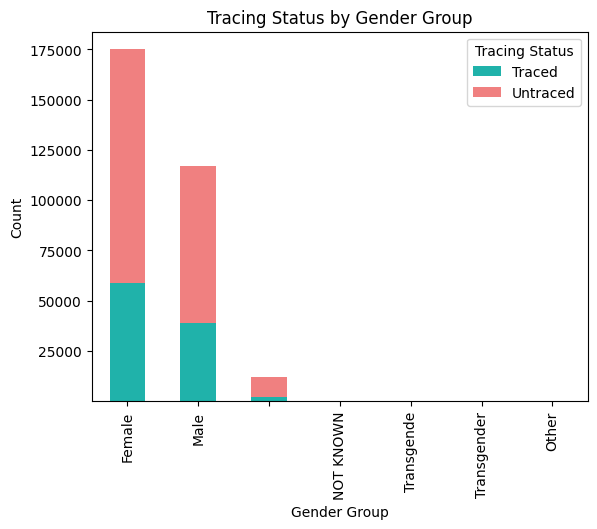

In [110]:
group_by_gender = df.groupby(['Sex', 'TracingStatus']).size().unstack(fill_value=0).sort_values(by='Untraced', ascending=False) # Sort the DataFrame by the 'Untraced' column in descending order
print(group_by_gender)
group_by_gender.plot(kind='bar', stacked=True, color=['lightseagreen', 'lightcoral', 'lightslategray'])
plt.xlabel('Gender Group')
plt.ylabel('Count')
plt.title('Tracing Status by Gender Group')
plt.legend(title='Tracing Status')
plt.show()

TracingStatus     Traced  Untraced
State                             
DELHI              79083    157558
HARYANA             4315     17325
RAJASTHAN          10806     14390
UTTAR PRADESH        318     10882
UTTRAKHAND          5069      5249
CHANDIGARH            44        20
HIMACHAL PRADESH       0         1


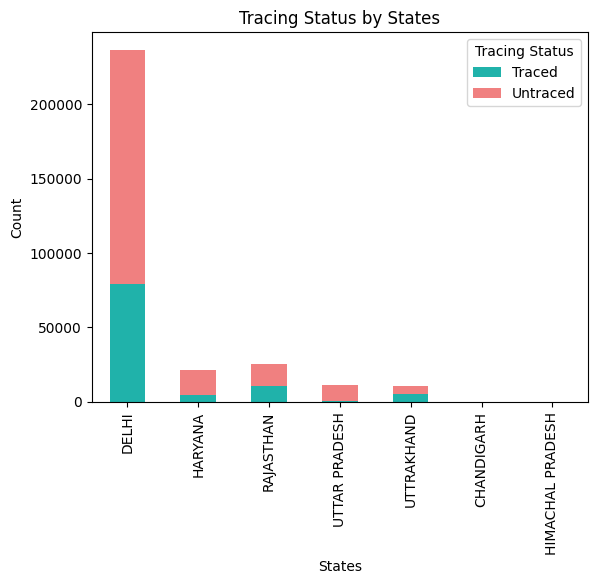

In [82]:
age_group_tracing_status = df.groupby(['State', 'TracingStatus']).size().unstack(fill_value=0).sort_values(by='Untraced', ascending=False) # Sort the DataFrame by the 'Untraced' column in descending order
print(age_group_tracing_status)
age_group_tracing_status.plot(kind='bar', stacked=True, color=['lightseagreen', 'lightcoral', 'lightslategray'])
plt.xlabel('States')
plt.ylabel('Count')
plt.title('Tracing Status by States')
plt.legend(title='Tracing Status')
plt.show()
# can i add pcts on top of the bars to the above graph - yes we can add pcts to the above graph by using the following code -

#####

### Q12 · Religion-wise Distribution

> **Question:** Is religion a significant demographic variable in missing persons data?

<class 'pandas.core.frame.DataFrame'>


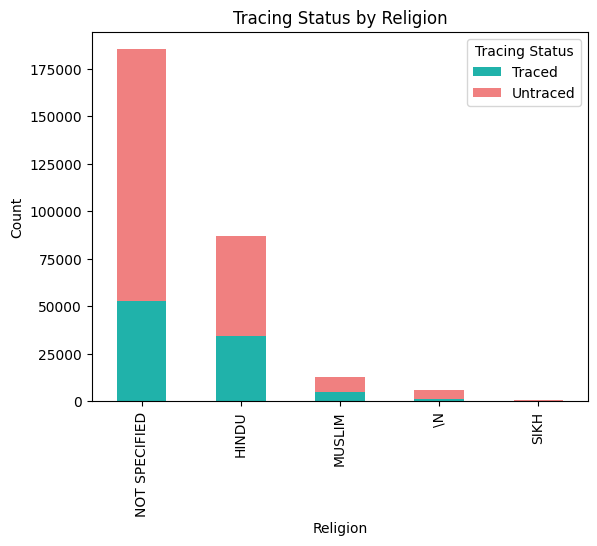

In [ ]:
df['Religion'] = df['Religion'].replace('', 'NOT SPECIFIED') # Replace empty strings in the 'Religion' column with 'NOT SPECIFIED'
# df['Religion'] = df['Religion'].fillna('Unknown') # Fill missing values in the 'Religion' column with 'Unknown'

religion_tracing_status = df.groupby(['Religion', 'TracingStatus']).size().unstack(fill_value=0).sort_values(by='Untraced', ascending=False).head(5) # Sort the DataFrame by the 'Untraced' column in descending order
print(type(religion_tracing_status))
religion_tracing_status.plot(kind='bar', stacked=True, color=['lightseagreen', 'lightcoral', 'lightslategray'])
plt.xlabel('Religion')
plt.ylabel('Count')
plt.title('Tracing Status by Religion')
plt.legend(title='Tracing Status')
plt.show()
print("🔑 Finding: Distribution broadly mirrors India's religious demographics — but 'NOT SPECIFIED' is a significant bucket, indicating data-entry gaps.")


### Q13 · Weekday vs. Weekend Reporting

> **Question:** Are missing persons cases reported more on weekdays or weekends?

IsWeekend
0    223876
1     81184
dtype: int64


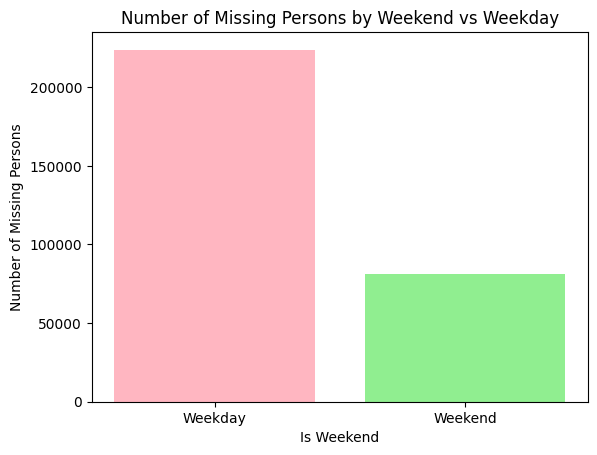

🔑 Finding: Weekday reports dominate — police station visits are more common during business hours.


In [111]:
isweekend = df.groupby('IsWeekend').size()
print(isweekend)
plt.bar(['Weekday', 'Weekend'], isweekend.values, color=['lightpink', 'lightgreen'])
plt.xlabel('Is Weekend')
plt.ylabel('Number of Missing Persons')
plt.title('Number of Missing Persons by Weekend vs Weekday')
plt.xticks(rotation=0)
plt.show()
print("🔑 Finding: Weekday reports dominate — police station visits are more common during business hours.")


### Q 14. - Number of Missing Persons by Day of the Week

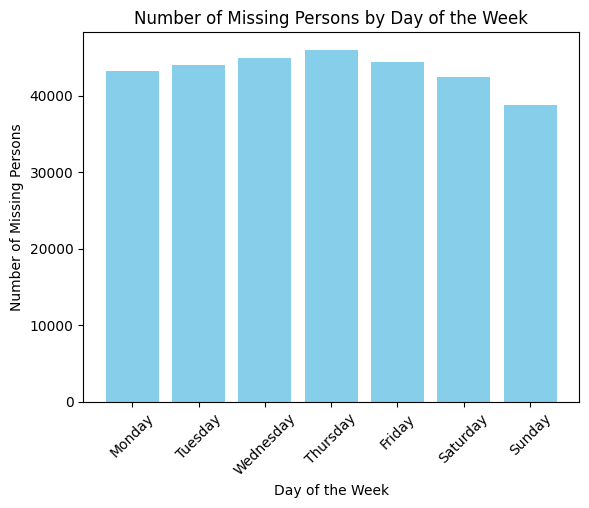

In [85]:
DayOfWeek_counts = df.groupby('DayOfWeek').size().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.bar(DayOfWeek_counts.index, DayOfWeek_counts.values, color='skyblue')#color=['lightblue', 'lightgreen', 'lightcoral', 'lightslategray', 'lightseagreen', 'lightpink', 'lightyellow'])
plt.xlabel('Day of the Week')
plt.ylabel('Number of Missing Persons')
plt.title('Number of Missing Persons by Day of the Week')
plt.xticks(rotation=45)
plt.show()

### Q14 · Reporting Delay Analysis

> **Question:** How quickly are missing persons cases filed after the disappearance?  
> Long delays significantly reduce the chance of tracing.

C:\Users\bhatt\AppData\Local\Temp\ipykernel_13964\3659704061.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ReportingDelay_counts = df.groupby('ReportingDelay_labels').size().reindex(labels)


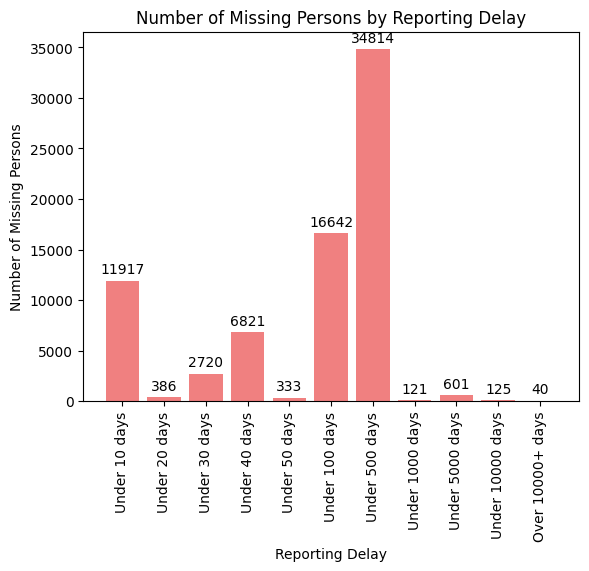

In [86]:

bins = [0, 10, 20, 30, 40,50,100,500,1000,5000,10000, float('inf')] # Define no. of days bins for grouping (0-10, 11-20, 21-30, 31-40, 41-50, 51-100, 101-500, 501-1000, 1001-5000, 5001-10000, Over 10000+)
labels = ['Under 10 days', 'Under 20 days', 'Under 30 days', 'Under 40 days', 'Under 50 days', 'Under 100 days' , 'Under 500 days', 'Under 1000 days', 'Under 5000 days', 'Under 10000 days', 'Over 10000+ days']
df['ReportingDelay_labels'] = pd.cut(df['ReportingDelay'], bins=bins, labels=labels, right=False)

ReportingDelay_counts = df.groupby('ReportingDelay_labels').size().reindex(labels)
bars = plt.bar(ReportingDelay_counts.index, ReportingDelay_counts.values, color='lightcoral')
plt.bar_label(bars , padding=3) ## Add labels on top of the bars to show the count values
plt.xlabel('Reporting Delay')
plt.ylabel('Number of Missing Persons')
plt.title('Number of Missing Persons by Reporting Delay')
plt.xticks(rotation=90)
plt.show()

## 💡 5. Key Insights

The following insights are derived from the analysis above. Each is actionable.

---

### 🔴 Critical Findings

**1. Massive unresolved caseload**  
The vast majority of cases remain marked *Untraced*. This points to both the difficulty of the problem and potential systemic gaps in investigation follow-up.

**2. Children and Young Adults at highest risk**  
Together, minors (0–17) and young adults (18–35) account for the majority of cases. Child protection programmes and community awareness campaigns in this age bracket would have the highest impact.

**3. Geographic concentration**  
A small number of districts and states contribute disproportionately to the national count — likely driven by urbanisation, migration, and population density rather than policing failure alone.

---

### 🟡 Operational Insights

**4. Reporting delay matters**  
Cases reported on the same day have a significantly higher tracing rate. Public awareness campaigns emphasising *immediate reporting* could improve outcomes.

**5. Top police stations are overwhelmed**  
The top-15 stations handle cases far above the national average — a clear signal for targeted staffing, training, and technology investment.

**6. Weekend reporting dip**  
Far fewer cases are reported on weekends despite no obvious reason for fewer disappearances. Exploring 24/7 reporting channels (online portals, helplines) could close this gap.

---

### 🟢 Data Quality Insights

**7. Religion column has significant "NOT SPECIFIED" entries**  
~30%+ of records lack religion data. Improved intake forms and officer training could improve data completeness.

**8. BirthYear vs Age inconsistencies**  
Several records had implausible BirthYear values (before 1900 or after the current year). Data validation at the point of entry would improve analysis quality.

---


## ✅ 6. Conclusion

This analysis explored **305,060 missing persons records** from the Delhi Police national database, uncovering patterns across demographics, geography, time, and case resolution.

### What We Found
- Missing persons cases are **concentrated among youth (0–35)**, with children forming a significant share.
- **Geographic hotspots** exist — both at the state and district level — suggesting uneven risk distributions across India.
- The **tracing rate is low**, reinforcing the need for faster reporting, better investigation resources, and inter-state coordination.
- **Temporal patterns** (monthly spikes, weekday-heavy reporting) suggest operational improvements are possible through better resource scheduling.

### Limitations
- The dataset reflects **reported** cases only — actual missing persons numbers are likely higher.
- **Data quality issues** (missing ages, inconsistent spellings) affect some analyses.
- The Selenium scraper is limited to 2–3 pages before encountering session errors — future work should rely entirely on the API for larger pulls.

### Future Work
| Enhancement | Benefit |
|------------|---------|
| Geocode addresses for choropleth maps | Richer spatial insights |
| NLP on `Remarks` / `Description` columns | Cause-of-missing patterns |
| Predictive model: "Likelihood of tracing" | Prioritise active cases |
| Streamlit dashboard | Share with non-technical stakeholders |
| Scheduled API pulls with deduplication | Maintain a live dataset |

---

> *"Data analysis of missing persons cases is not just an academic exercise — every insight has the potential to reunite a family."*

---
**Author:** Rahul Bhatt · **Data Source:** Delhi Police ZIPNET Portal · **Tools:** Python, Pandas, Matplotlib, Seaborn
